## Importando bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Lendo a base

In [2]:
df_normalizada = pd.read_excel("C:/Users/Igor/Documents/Teste Analista de MIS/Bases Secundarias/tb_normalizada.xlsx")

## 1º - Identificar a distribuição de chamadas por operador e cliente.

### 1.1 - Chamadas por operador

Primeiramente vou verificar a quantidade distinta de operadores:

In [3]:
df_normalizada['nome_operador'].nunique()

390

Devido a quantidade grande de operadores, será inviável plotar essa quantidade em um gráfico. Devido a isso, vou limitar aos 20 operadores com mais chamadas:

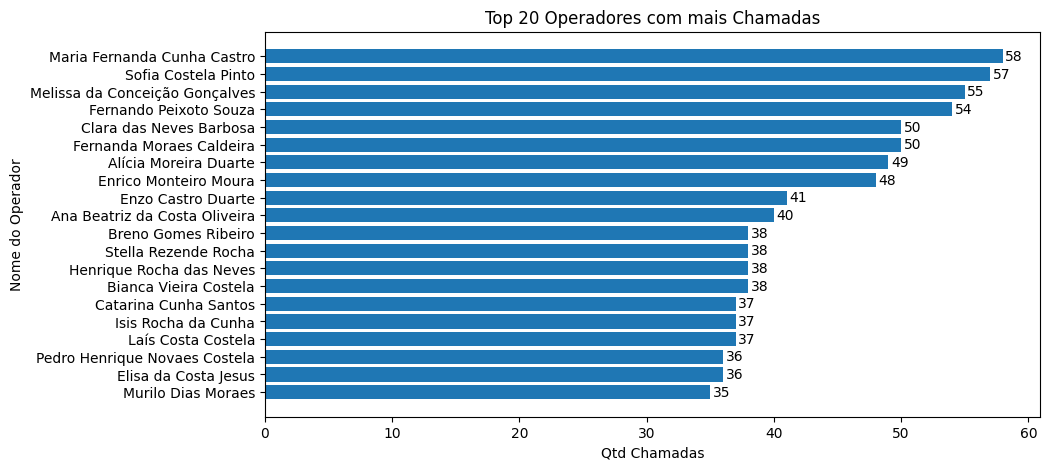

In [4]:
top20_chamadas_operador = df_normalizada['nome_operador'].value_counts().head(20)

# Inverte a ordem pra colocar o maior em cima
nomes = top20_chamadas_operador.index[::-1]
valores = top20_chamadas_operador.values[::-1]

# Plotando
plt.figure(figsize=(10, 5))
plt.barh(nomes, valores)
plt.title('Top 20 Operadores com mais Chamadas')
plt.xlabel('Qtd Chamadas')
plt.ylabel('Nome do Operador')

# Adicionando rótulos de dados
for i, v in enumerate(valores):
    plt.text(v + 0.2, i, str(v), va='center') 

plt.show()

Agora, vou fazer ao inverso, descobrir os 20 com menos chamadas:

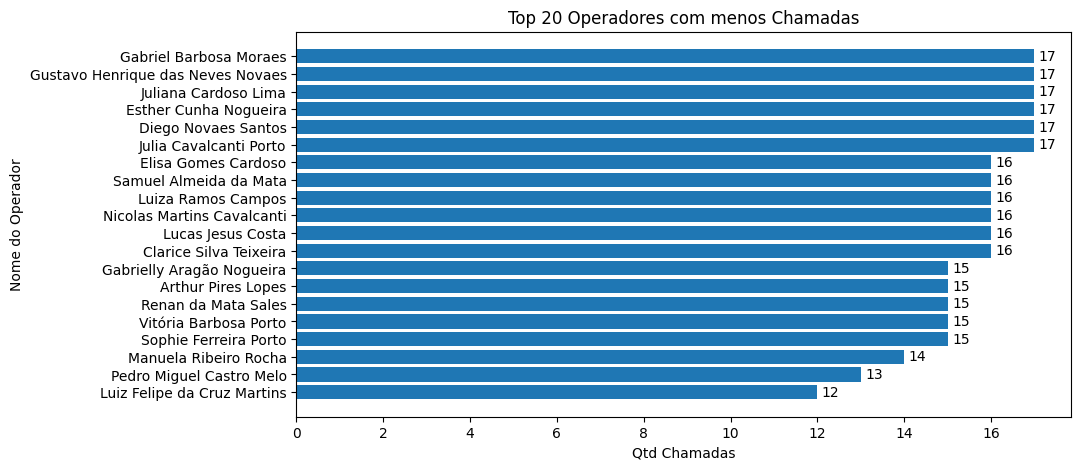

In [5]:
tail20_chamadas_operador = df_normalizada['nome_operador'].value_counts().tail(20)

# Inverte a ordem pra colocar o menor em cima
nomes = tail20_chamadas_operador.index[::-1]
valores = tail20_chamadas_operador.values[::-1]

# Plotando
plt.figure(figsize=(10, 5))
plt.barh(nomes, valores)
plt.title('Top 20 Operadores com menos Chamadas')
plt.xlabel('Qtd Chamadas')
plt.ylabel('Nome do Operador')

# Adicionando rótulos de dados
for i, v in enumerate(valores):
    plt.text(v + 0.1, i, str(v), va='center') 

plt.show()

Por fim, apenas para complementar a análise, vou verificar em média quantas chamadas são atendidas por operador:

In [6]:
# Agrupando por nome_operador e realizando uma contagem
df_normalizada_agrupado_nome_op = df_normalizada.groupby('nome_operador').agg(qtd=('recebido', 'count')).reset_index().sort_values(by='qtd', ascending=True)

# Calculando a média
media_chamadas_operador = df_normalizada_agrupado_nome_op['qtd'].mean()
print(media_chamadas_operador)

25.453846153846154


Em média, cada operador realiza/recebe aproximadamente 25 chamadas.

### 1.2 - Chamadas por cliente

Vou verificar a quantidade distinta de clientes:

In [7]:
df_normalizada['nome_cli'].nunique()

57

Assim como com os operadores, temos muitos clientes na base. Portanto, irei usar a mesma lógica e filtrar apenas os 20 com mais ligações e os 20 com menos ligações:

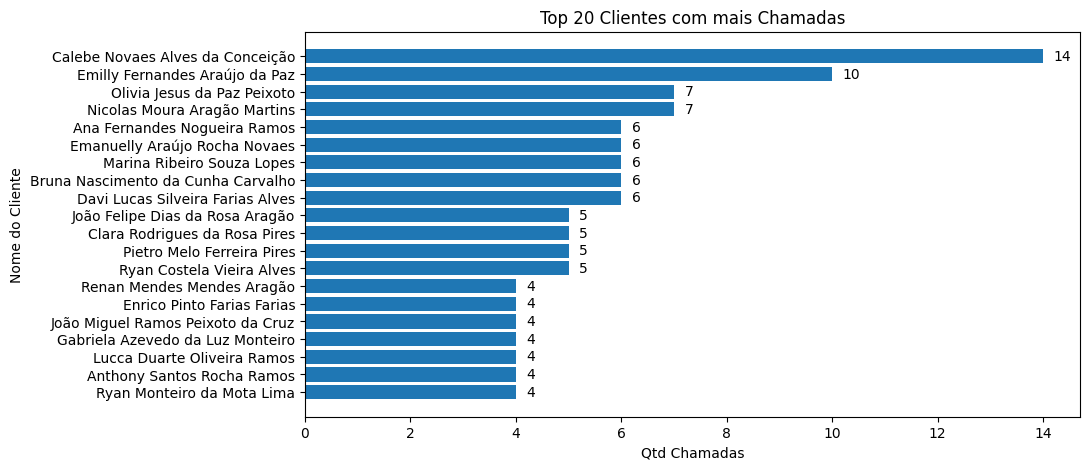

In [8]:
top20_chamadas_clientes = df_normalizada['nome_cli'].value_counts().head(20)

# Inverte a ordem pra colocar o maior em cima
nomes = top20_chamadas_clientes.index[::-1]
valores = top20_chamadas_clientes.values[::-1]

# Plotando
plt.figure(figsize=(10, 5))
plt.barh(nomes, valores)
plt.title('Top 20 Clientes com mais Chamadas')
plt.xlabel('Qtd Chamadas')
plt.ylabel('Nome do Cliente')

# Adicionando rótulos de dados
for i, v in enumerate(valores):
    plt.text(v + 0.2, i, str(v), va='center') 

plt.show()

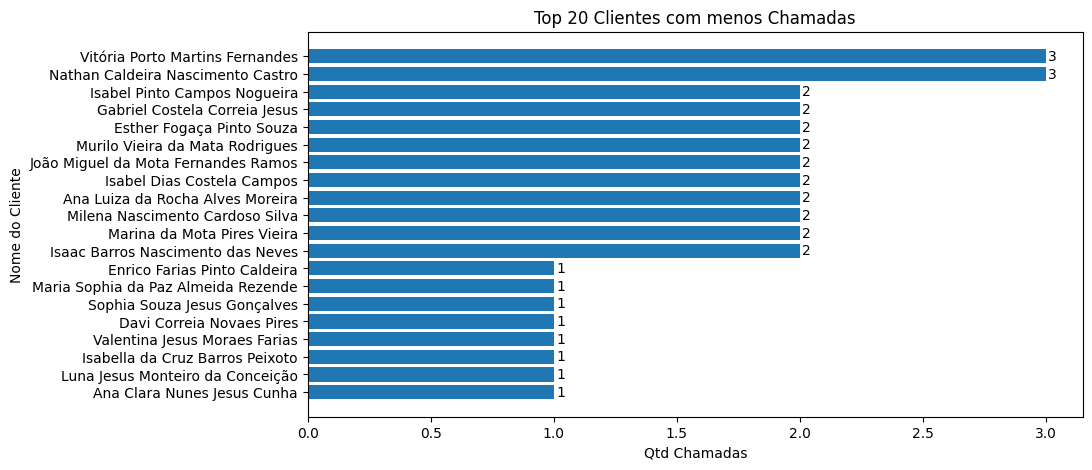

In [9]:
tail20_chamadas_clientes = df_normalizada['nome_cli'].value_counts().tail(20)

# Inverte a ordem pra colocar o menor em cima
nomes = tail20_chamadas_clientes.index[::-1]
valores = tail20_chamadas_clientes.values[::-1]

# Plotando
plt.figure(figsize=(10, 5))
plt.barh(nomes, valores)
plt.title('Top 20 Clientes com menos Chamadas')
plt.xlabel('Qtd Chamadas')
plt.ylabel('Nome do Cliente')

# Adicionando rótulos de dados
for i, v in enumerate(valores):
    plt.text(v + 0.01, i, str(v), va='center') 

plt.show()

## 2º - Analisar o tempo médio de espera e atendimento por operador.

Primeiramente vou verificar as tipagens

In [10]:
df_normalizada[['tempo_atendimento', 'tempo_espera']].dtypes

tempo_atendimento    object
tempo_espera         object
dtype: object

Ambas as colunas de interesse estão como string, portanto irei corrigir isso:

In [11]:
df_normalizada['tempo_espera'] = pd.to_timedelta(df_normalizada['tempo_espera'])
df_normalizada['tempo_atendimento'] = pd.to_timedelta(df_normalizada['tempo_atendimento'])


Validando as alterações:

In [12]:
df_normalizada[['tempo_atendimento', 'tempo_espera']].dtypes

tempo_atendimento    timedelta64[ns]
tempo_espera         timedelta64[ns]
dtype: object

In [13]:
df_normalizada.head()

,data,hora,retido_ura,recebido,atendido,tempo_espera,tempo_atendimento,telefone,id_operador,nome_operador,tabulacao,subtabulacao,carga_horaria,equipe,supervisor,cpf_cli,nome_cli,estado_cli,cidade_cli,cep_cli
0,2025-01-29,21:29:18,0,1,0,0 days 00:00:52,0 days 00:03:53,79466408074,142012,Luna Ferreira da Rocha,4. Canal de Atendimento,4.2 E-mail,7h12,Platina,Vitor Duarte Porto,NaN,NaN,NaN,NaN,NaN
1,2025-01-07,00:16:27,0,1,1,0 days 00:00:45,0 days 00:08:34,27726765896,1752,Levi Cunha da Costa,2. Status do Atendimento,2.4 Em Análise,7h12,Prata,Isabel da Mota da Luz,NaN,NaN,NaN,NaN,NaN
2,2025-01-05,06:46:34,1,0,0,0 days 00:00:24,0 days 00:03:31,23641477161,31913,Helena Costa Ferreira,6. Ação Tomada,6.4 Devolução/Reembolso,7h12,Platina,Rebeca Teixeira da Rosa,NaN,NaN,NaN,NaN,NaN
3,2025-01-24,14:57:04,0,1,1,0 days 00:01:06,0 days 00:07:09,85496119020,11204,João Costela Viana,4. Canal de Atendimento,4.2 E-mail,7h12,Platina,Isabel da Mota da Luz,NaN,NaN,NaN,NaN,NaN
4,2025-01-27,23:55:41,0,1,1,0 days 00:01:43,0 days 00:03:44,33634550482,2134,Ian Pires Peixoto,5. Grau de Satisfação,5.1 Muito Satisfeito,7h12,Platina,Nina Mendes Gonçalves,NaN,NaN,NaN,NaN,NaN


Certo, agora vou calcular as médias:

In [14]:
media_espera_operador = df_normalizada['tempo_espera'].mean()
media_atendimento_operador = df_normalizada['tempo_atendimento'].mean()

Exibindo os dados:

In [15]:
print(f"Tempo médio de espera: {str(media_espera_operador).split('.')[0]}")
print(f"Tempo médio de atendimento: {str(media_atendimento_operador).split('.')[0]}")

Tempo médio de espera: 0 days 00:00:59
Tempo médio de atendimento: 0 days 00:05:29


Portanto, podemos verificar que:

Tempo médio de espera: 59 segundos
Tempo médio de atendimento: 5 minutos e 29 segundos.

### 2.1 - Tempo médio de espera por operador (TOP20)

In [16]:
df_normalizada_tempo_med_op_espera = df_normalizada.copy()
df_normalizada_tempo_med_op_espera = df_normalizada_tempo_med_op_espera.groupby(['nome_operador']).agg({
    'tempo_espera' : 'mean',
})

# Ordenando os dados pelo maior tempo de espera
df_normalizada_tempo_med_op_espera = df_normalizada_tempo_med_op_espera.sort_values(by='tempo_espera', ascending=False)

# Substituindo a forma como os dados são exibidos na coluna 'tempo_espera' para melhorar a visualização
df_normalizada_tempo_med_op_espera['tempo_espera'] = df_normalizada_tempo_med_op_espera['tempo_espera'].apply(
    lambda x: f"{x.components.hours:02}:{x.components.minutes:02}:{x.components.seconds:02}"
)

Verificando os dados:

In [17]:
df_normalizada_tempo_med_op_espera.head(20)

,tempo_espera
nome_operador,
Yasmin Mendes Moreira,00:01:18
Clara da Cunha da Costa,00:01:16
Lucas Jesus Costa,00:01:16
Gabriel Barbosa Moraes,00:01:15
Caio Gomes Sales,00:01:15
Fernando da Rocha Campos,00:01:14
Maria Sophia Rodrigues Lopes,00:01:14
Maria Clara Costa Oliveira,00:01:14
Fernando Campos Duarte,00:01:13


### 2.2 - Tempo médio de atendimento por operador (TOP20)

In [18]:
df_normalizada_tempo_med_op_atend = df_normalizada.copy()
df_normalizada_tempo_med_op_atend = df_normalizada_tempo_med_op_atend.groupby(['nome_operador']).agg({
    'tempo_atendimento' : 'mean',
})

# Ordenando os dados pelo maior tempo de atend
df_normalizada_tempo_med_op_atend = df_normalizada_tempo_med_op_atend.sort_values(by='tempo_atendimento', ascending=False)

# Substituindo a forma como os dados são exibidos na coluna 'tempo_atendimento' para melhorar a visualização
df_normalizada_tempo_med_op_atend['tempo_atendimento'] = df_normalizada_tempo_med_op_atend['tempo_atendimento'].apply(
    lambda x: f"{x.components.hours:02}:{x.components.minutes:02}:{x.components.seconds:02}"
)

Verificando os dados:

In [19]:
df_normalizada_tempo_med_op_atend.head(20)

,tempo_atendimento
nome_operador,
Luiz Felipe da Cruz Martins,00:07:18
João Teixeira Fogaça,00:07:00
Igor da Paz Cunha,00:06:52
Arthur Silva Duarte,00:06:38
Amanda da Luz Azevedo,00:06:33
Manuela Ribeiro Rocha,00:06:33
Marcelo da Cunha Fernandes,00:06:31
André da Rocha Jesus,00:06:30
Gustavo Henrique das Neves Novaes,00:06:29


## 3º - Verificar o volume de chamadas por tabulação e subtabulação.

Plotando o gráfico de volume de chamadas por tabulação:

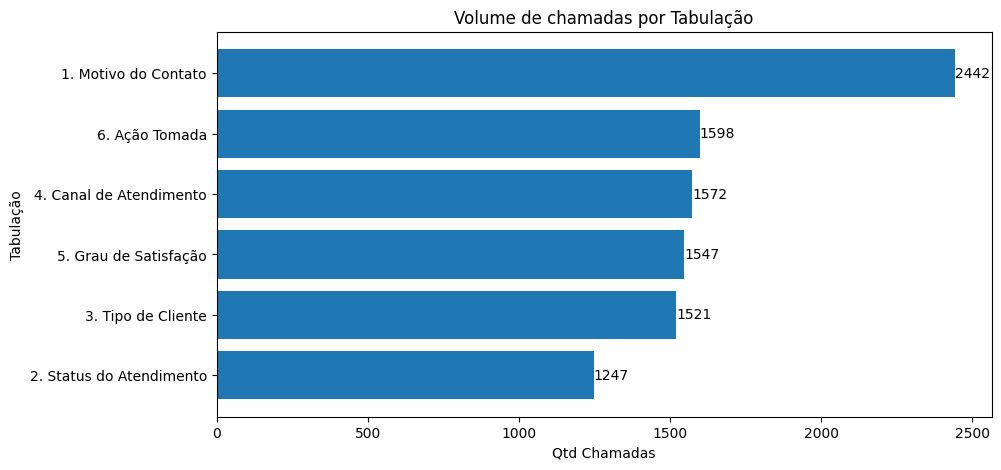

In [20]:
tabulacoes = df_normalizada['tabulacao'].value_counts()

# Inverte a ordem pra colocar o maior em cima
nomes = tabulacoes.index[::-1]
valores = tabulacoes.values[::-1]

# Plotando
plt.figure(figsize=(10, 5))
plt.barh(nomes, valores)
plt.title('Volume de chamadas por Tabulação')
plt.xlabel('Qtd Chamadas')
plt.ylabel('Tabulação')

# Adicionando rótulos de dados
for i, v in enumerate(valores):
    plt.text(v + 0.5, i, str(v), va='center') 

plt.show()

Plotando o gráfico de volume de chamadas por subtabulação:

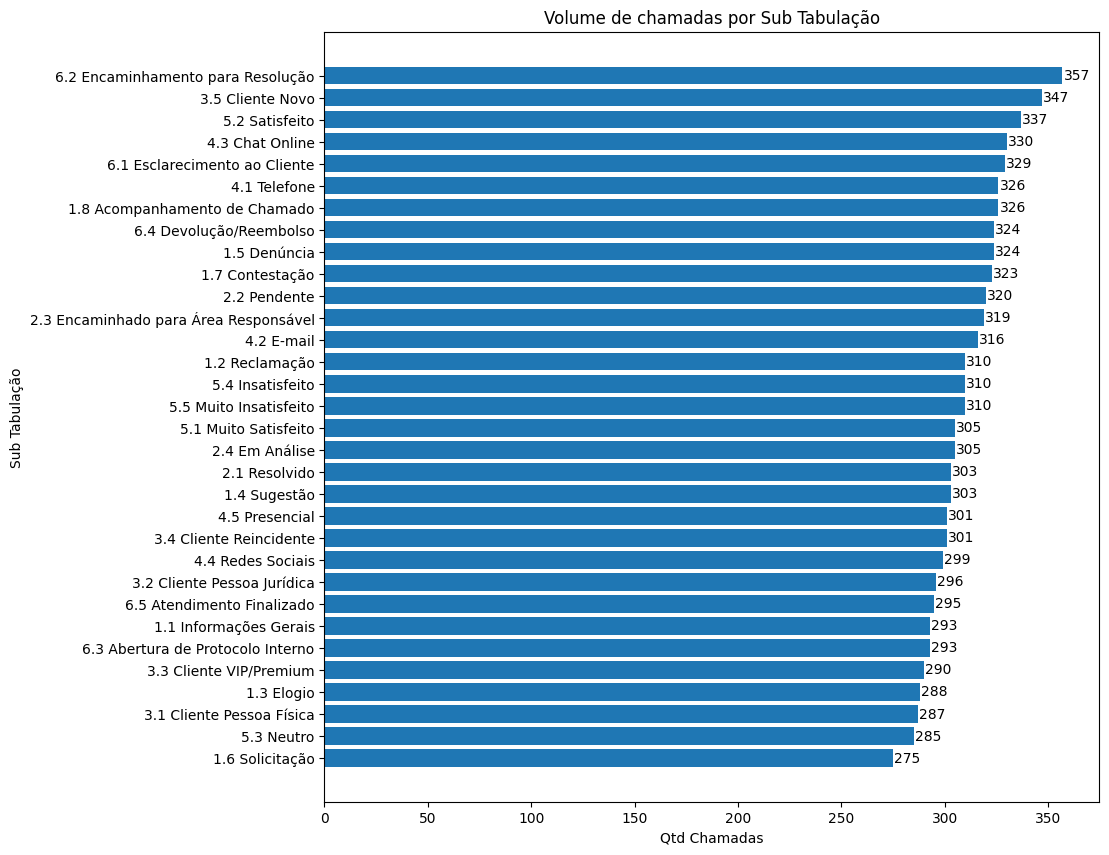

In [21]:
subtab = df_normalizada['subtabulacao'].value_counts()

# Inverte a ordem pra colocar o maior em cima
nomes = subtab.index[::-1]
valores = subtab.values[::-1]

# Plotando
plt.figure(figsize=(10, 10))
plt.barh(nomes, valores)
plt.title('Volume de chamadas por Sub Tabulação')
plt.xlabel('Qtd Chamadas')
plt.ylabel('Sub Tabulação')

# Adicionando rótulos de dados
for i, v in enumerate(valores):
    plt.text(v + 0.5, i, str(v), va='center') 

plt.show()

## 4º - Identificar padrões de atendimento por dia e horário.

### 4.1 - Por dia

Vou analisar quais dias possuem mais atendimentos. Com base na coluna 'atendido', os valores que me retorna é 0 e 1. Considerando que 0 = não atendido e 1 = atendido:

Para isso, vou agrupar os valores por data, transformando o 1 e 0 em atendido e não atendido:

In [22]:
df_qtd_dia = df_normalizada.groupby('data')['atendido'].value_counts().unstack(fill_value=0)
df_qtd_dia.columns = ['nao_atendido', 'atendido']
df_qtd_dia = df_qtd_dia.reset_index()

Alterando a formatação da coluna de data:

In [23]:
df_qtd_dia['data'] = pd.to_datetime(df_qtd_dia['data']).dt.strftime('%d/%m/%Y')

Plotando o gráfico:

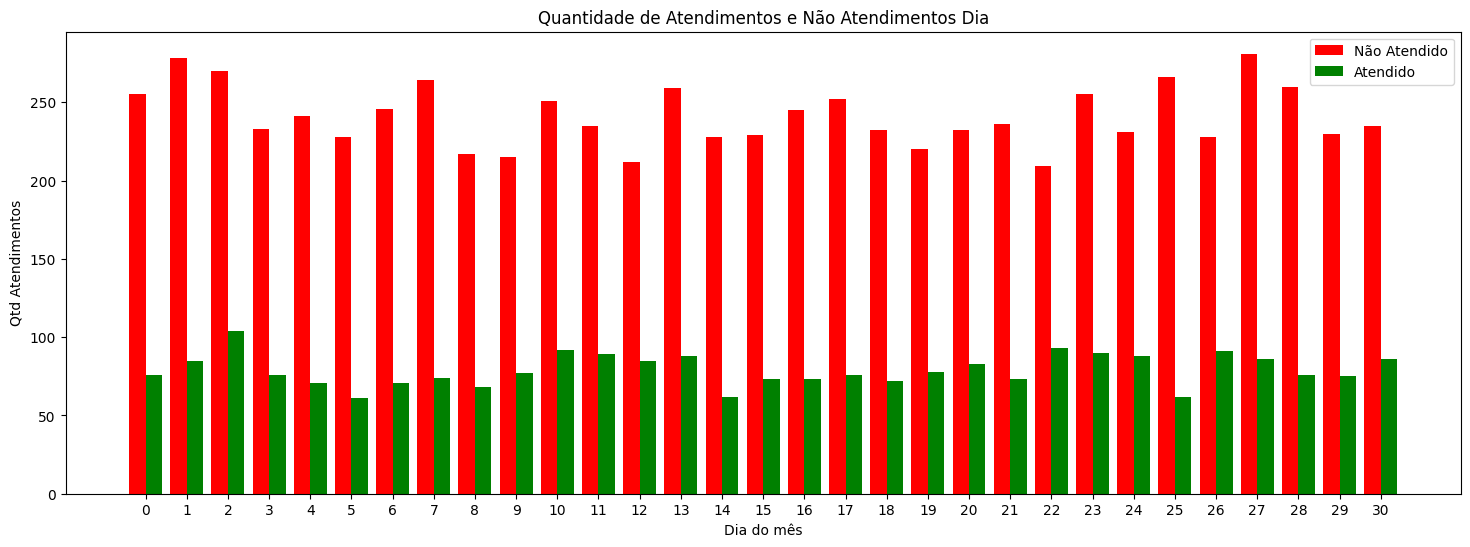

In [24]:
datas = df_qtd_dia.index
x = np.arange(len(datas))
largura = 0.4

plt.figure(figsize=(18, 6))
plt.bar(x - largura/2, df_qtd_dia['nao_atendido'], width=largura, label='Não Atendido', color='red')
plt.bar(x + largura/2, df_qtd_dia['atendido'], width=largura, label='Atendido', color='green')

plt.xticks(ticks=x, labels=datas)
plt.xlabel('Dia do mês')
plt.ylabel('Qtd Atendimentos')
plt.title('Quantidade de Atendimentos e Não Atendimentos Dia')
plt.legend()
plt.show()

In [25]:
df_qtd_dia.head()

,data,nao_atendido,atendido
0,01/01/2025,255,76
1,02/01/2025,278,85
2,03/01/2025,270,104
3,04/01/2025,233,76
4,05/01/2025,241,71


Analisando o gráfico de atendimentos por dia, pode-se concluir que não há nenhuma data que chame a atenção, tanto para chamadas Atendidas quanto para chamadas Não Atendidas.

O óbvio que percebe-se é que a maioria esmagadora das chamadas não são atendidas, para obter um dado mais preciso vou verificar o % de chamadas atendidas por dia:

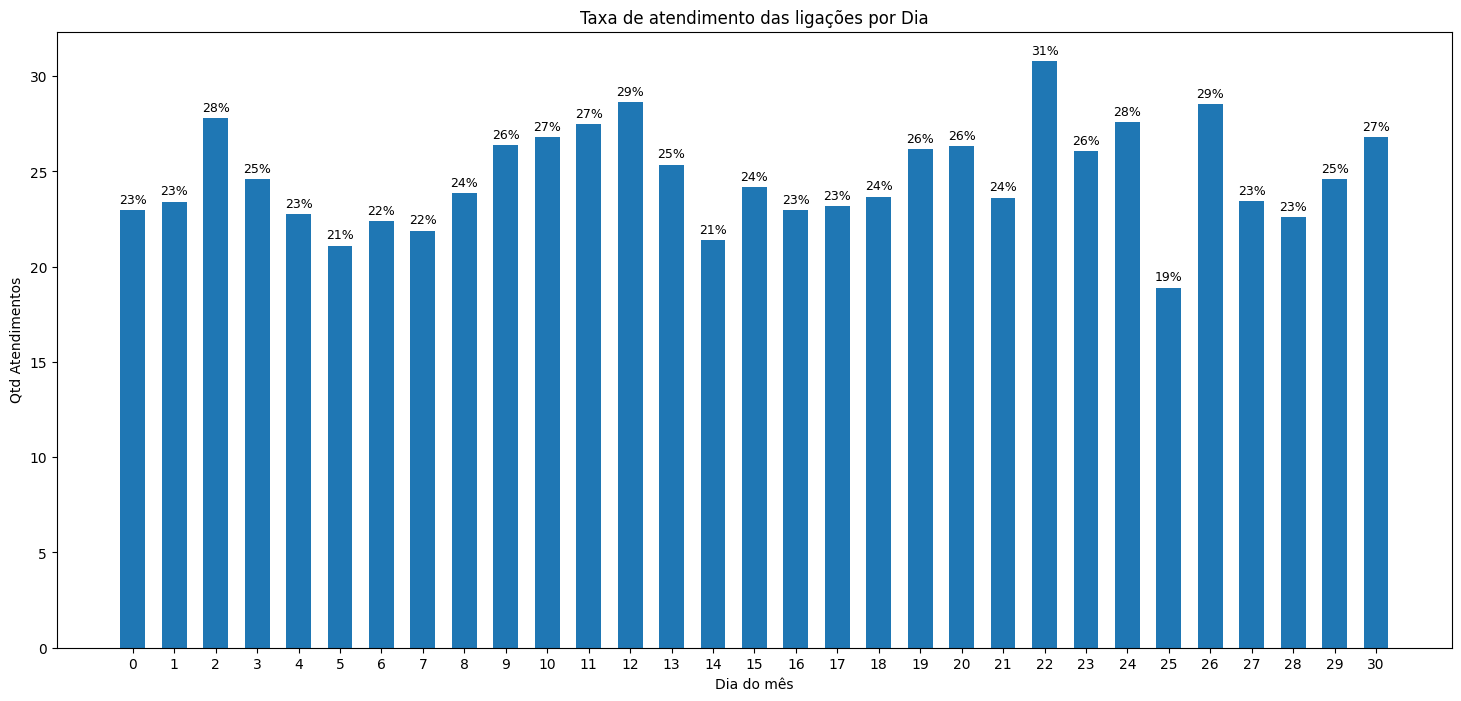

In [26]:
# Calculando a porcentagem de atendimentos
df_qtd_dia['percentual_atendido'] = (df_qtd_dia['atendido'] / (df_qtd_dia['atendido'] + df_qtd_dia['nao_atendido'])) * 100

datas = df_qtd_dia.index
x = np.arange(len(datas))
largura = 0.4

plt.figure(figsize=(18, 8))
plt.bar(x, df_qtd_dia['percentual_atendido'], width=0.6)

# Inserir rótulos acima das barras
for i, valor in enumerate(df_qtd_dia['percentual_atendido']):
    plt.text(i, valor + 0.2, f'{valor:.0f}%', ha='center', va='bottom', fontsize=9)

plt.xticks(ticks=x, labels=datas)
plt.xlabel('Dia do mês')
plt.ylabel('Qtd Atendimentos')
plt.title('Taxa de atendimento das ligações por Dia')
plt.show()

Certo, agora sim é possível verificar de forma mais fácil algumas variações.

O dia 25 chama a atenção negativamente, é o dia com a menor taxa de atendimentos com apenas 19%. Dia 05 é o segundo dia com a menor taxa, analisando melhor verifico que dia 25 é sábado e dia 05 é domingo, ou seja, é esperado e talvez um comportamento natural que a taxa de atendimentos de fato seja menor aos finais de semana.

O dia 22 chama a atenção positivamente, é o dia com a maior taxa de atendimentos com 30%. Verificando, essa data foi uma quarta feira que, analisando por si só, não há um motivo óbvio que justifique essa taxa mais alta. Alguns fatores ocultos podem explicar, como por exemplo, campanhas de SMS. Dia 12 vem em sequência como o segundo melhor dia sendo um domingo, com 29%

Com base nisso, verifcando que dia 05 e 12 sendo domingo, e dia 05 sendo o segundo pior dia e dia 12 sendo o segundo melhor, isso basicamente resume a análise como um todo: não há grandes variações, a taxa de atendimento é estável e padrão ao longo de todo o mês.

Porém, para complementar ainda mais a análise, vou verificar a média e o desvio padrão:

In [27]:
media_dia = df_qtd_dia['percentual_atendido'].mean()
desvio_dia = df_qtd_dia['percentual_atendido'].std()
print(f'Média: {media_dia}')
print(f'Desvio padrão:_dia {desvio_dia}')


Média: 24.71858904684549
Desvio padrão:_dia 2.6166242184547768


Com isso, estatisticamente quando o desvio padrão é < 3% podemos inferir que há baixa dispersão, corroborando com a análise feita acima.

In [28]:
df_normalizada['horario'] = df_normalizada['hora']

### 4.2 - Por hora

In [29]:
df_normalizada['hora'] = pd.to_timedelta(df_normalizada['hora'], errors='coerce').dt.components['hours']

In [30]:
df_normalizada.head()

,data,hora,retido_ura,recebido,atendido,tempo_espera,tempo_atendimento,telefone,id_operador,nome_operador,...,subtabulacao,carga_horaria,equipe,supervisor,cpf_cli,nome_cli,estado_cli,cidade_cli,cep_cli,horario
0,2025-01-29,21,0,1,0,0 days 00:00:52,0 days 00:03:53,79466408074,142012,Luna Ferreira da Rocha,...,4.2 E-mail,7h12,Platina,Vitor Duarte Porto,NaN,NaN,NaN,NaN,NaN,21:29:18
1,2025-01-07,0,0,1,1,0 days 00:00:45,0 days 00:08:34,27726765896,1752,Levi Cunha da Costa,...,2.4 Em Análise,7h12,Prata,Isabel da Mota da Luz,NaN,NaN,NaN,NaN,NaN,00:16:27
2,2025-01-05,6,1,0,0,0 days 00:00:24,0 days 00:03:31,23641477161,31913,Helena Costa Ferreira,...,6.4 Devolução/Reembolso,7h12,Platina,Rebeca Teixeira da Rosa,NaN,NaN,NaN,NaN,NaN,06:46:34
3,2025-01-24,14,0,1,1,0 days 00:01:06,0 days 00:07:09,85496119020,11204,João Costela Viana,...,4.2 E-mail,7h12,Platina,Isabel da Mota da Luz,NaN,NaN,NaN,NaN,NaN,14:57:04
4,2025-01-27,23,0,1,1,0 days 00:01:43,0 days 00:03:44,33634550482,2134,Ian Pires Peixoto,...,5.1 Muito Satisfeito,7h12,Platina,Nina Mendes Gonçalves,NaN,NaN,NaN,NaN,NaN,23:55:41


In [31]:
df_qtd_hora = df_normalizada.groupby('hora')['atendido'].value_counts().unstack(fill_value=0)
df_qtd_hora.columns = ['nao_atendido', 'atendido']
df_qtd_hora = df_qtd_hora.reset_index()

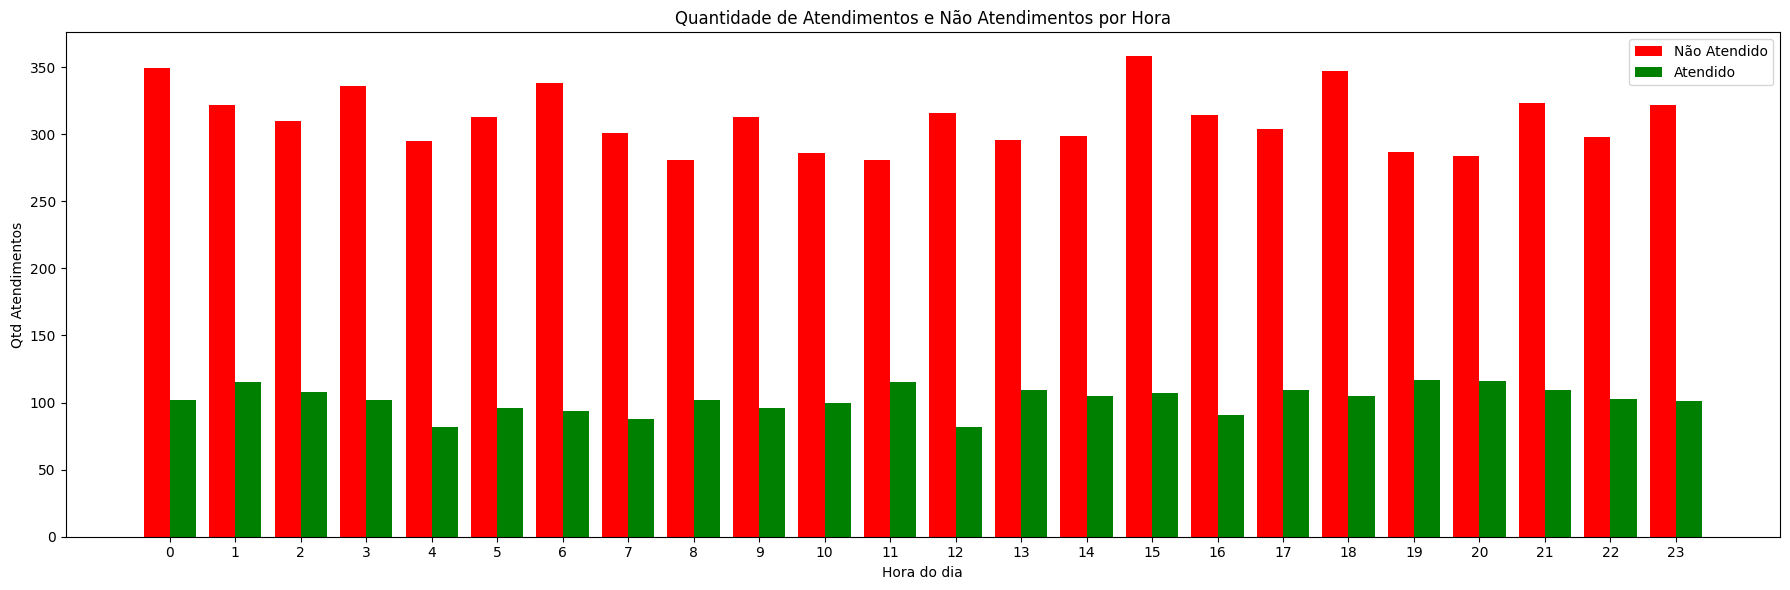

In [32]:
datas = df_qtd_hora.index
x = np.arange(len(datas))
largura = 0.4

plt.figure(figsize=(18, 6))
plt.bar(x - largura/2, df_qtd_hora['nao_atendido'], width=largura, label='Não Atendido', color='red')
plt.bar(x + largura/2, df_qtd_hora['atendido'], width=largura, label='Atendido', color='green')

plt.xticks(ticks=x, labels=datas)
plt.xlabel('Hora do dia')
plt.ylabel('Qtd Atendimentos')
plt.title('Quantidade de Atendimentos e Não Atendimentos por Hora')
plt.legend()
plt.tight_layout()
plt.show()

Bem como o gráfico plotado de análise por Dia, o gráfico de quantidade de atendimentos e não atendimentos por hora não nos diz muita coisa por si só, além do óbvio novamente: as chamadas mais são não atendidas do que o contrário.

Da mesma maneira como na análise anterior, irei verificar a taxa de atendimentos, dessa vez por hora:

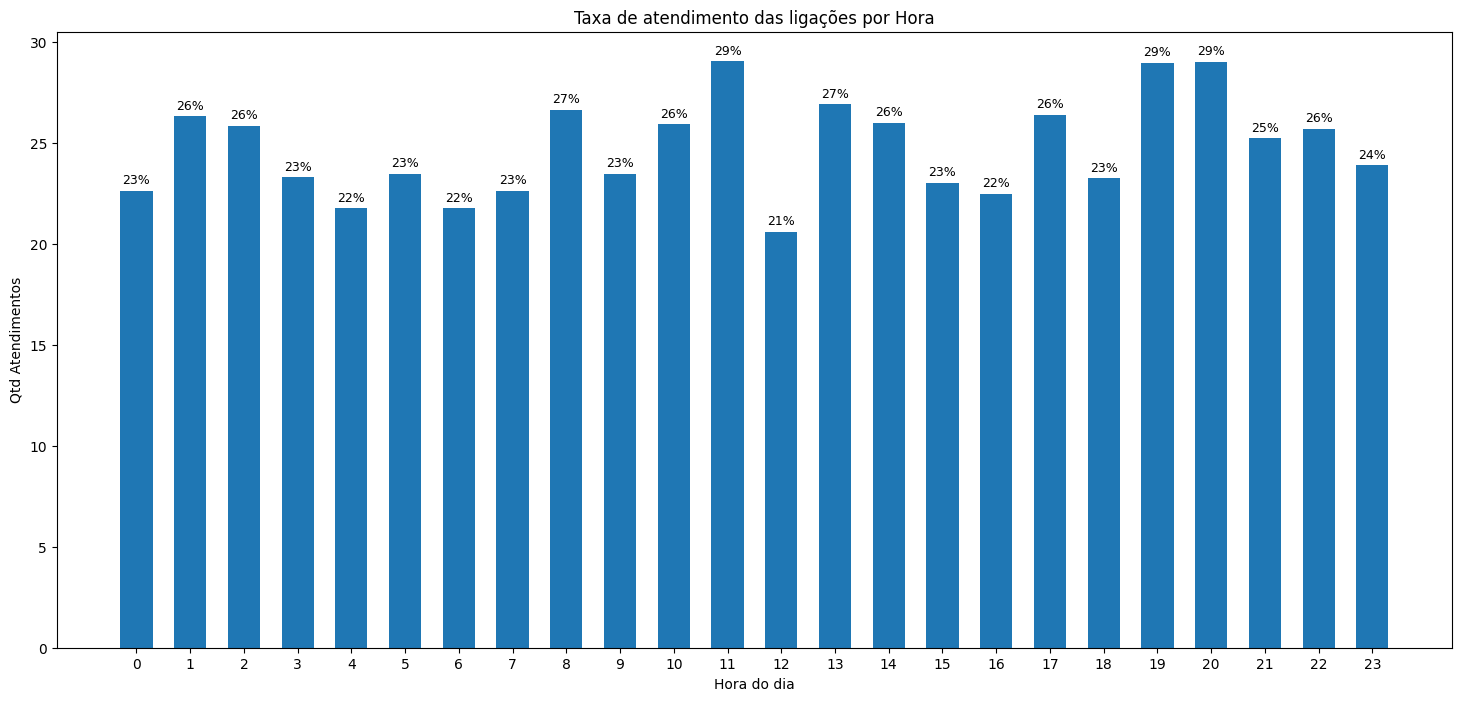

In [33]:
# Primeiro, calcular a porcentagem de atendimentos
df_qtd_hora['percentual_atendido'] = (df_qtd_hora['atendido'] / (df_qtd_hora['atendido'] + df_qtd_hora['nao_atendido'])) * 100

datas = df_qtd_hora.index
x = np.arange(len(datas))
largura = 0.4

plt.figure(figsize=(18, 8))
plt.bar(x, df_qtd_hora['percentual_atendido'], width=0.6)

# Inserir rótulos acima das barras
for i, valor in enumerate(df_qtd_hora['percentual_atendido']):
    plt.text(i, valor + 0.2, f'{valor:.0f}%', ha='center', va='bottom', fontsize=9)

plt.xticks(ticks=x, labels=datas)
plt.xlabel('Hora do dia')
plt.ylabel('Qtd Atendimentos')
plt.title('Taxa de atendimento das ligações por Hora')
plt.show()

Percebe-se o mesmo comportamento da análise por dia, não há um horário específico que chame a atenção tanto pra mais atendimentos quanto para menos. Fato é que há de se descobrir o porque de uma maior taxa de 29% em alguns horários e trabalhar para que isso possa ser replicado nos demais horários, sobretudo nos de menores taxas, como por exemplo 12hrs e 15hrs, afim de aumentar a taxa média de atendimentos, assim como na análise por dia.

Farei a seguir a mesma análise com a média e o desvio padrão:

In [34]:
media_hr = df_qtd_dia['percentual_atendido'].mean()
desvio_hr = df_qtd_dia['percentual_atendido'].std()
print(f'Média: {media_hr}')
print(f'Desvio padrão: {desvio_hr}')


Média: 24.71858904684549
Desvio padrão: 2.6166242184547768


Novamente nota-se o desvio padrão abaixo dos 3%, provando estatisticamente que não há grande variação nos dados exibidos. Além disso percebe-se a média em aproximadamente 25% das chamadas atendidas por hora, porcentagem essa que pode ser trabalhada para obter um valor mais próximo das maiores taxas, em torno de 29%.